In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from math import ceil
from scipy.stats import gaussian_kde
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import random

from scipy.linalg import orthogonal_procrustes
from scipy.linalg import solve
from scipy.linalg import orthogonal_procrustes


try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

In [66]:
cu2mci_proteomics = pd.read_csv("../data/GNPC_Harmonized_Dataset_V1/cu2mci_proteomics_data.csv")
cu2mci_proteomics.head()

,person_id,sample_id,sex,contributor_code,sample_type,visit,age_at_visit,ad,ftd,pd,...,seq_9984_12,seq_9986_14,seq_9987_30,seq_9989_12,seq_9991_112,seq_9993_11,seq_9994_217,seq_9995_6,seq_9997_12,seq_9999_1
0,f9e2f741-a44a-4ce2-9a83-b4a9028f6427,a99cd012-ae2d-4d3d-9b1e-5c8f588c6396,1,B,Sample,2,64,0,0,0,...,566.1,3653.5,550.3,400.1,834.7,1145.3,1531.4,8447.4,37763.3,3512.4
1,426976f1-388f-4fd9-b39c-b582912b108f,f12137ff-9807-4ed4-b071-c55da84318d7,2,B,Sample,2,65,0,0,0,...,581.9,1034.0,534.9,347.9,459.4,1700.4,1440.7,11518.2,29796.5,5313.6
2,9d0094df-3bc2-4837-989d-6028720d5a66,9d0094df-3bc2-4837-989d-6028720d5a66,2,I,Sample,1,63,-1,-1,-1,...,539.3,5499.5,508.9,411.9,474.6,950.0,1280.6,4655.7,37296.3,4156.4
3,d4d11a95-e9b0-4408-9bf9-cf67bef3de83,d4d11a95-e9b0-4408-9bf9-cf67bef3de83,1,B,Sample,1,50,0,0,0,...,614.7,3337.4,658.4,413.7,559.4,1200.4,1437.3,1986.8,11742.5,1284.7
4,c64c810f-7e38-4105-89a2-3d5c1de98e0e,c64c810f-7e38-4105-89a2-3d5c1de98e0e,2,B,Sample,1,65,0,0,0,...,617.3,2094.7,596.1,407.8,697.9,1105.7,1359.2,2022.5,16409.8,2566.4


In [79]:
proteomics_cols = [c for c in cu2mci_proteomics.columns if c.startswith("seq_")]

cols_with_nan_or_minus1 = [
    c for c in proteomics_cols
    if cu2mci_proteomics[c].isna().any() or (cu2mci_proteomics[c] == -1).any()
]
cu2mci_proteomics_clean = cu2mci_proteomics.drop(columns=cols_with_nan_or_minus1)

In [80]:
patient_dict = {
    pid: pdf.sort_values("visit")
    for pid, pdf in cu2mci_proteomics_clean.groupby("person_id")
}


In [82]:
clean_proteomics_cols = [c for c in cu2mci_proteomics_clean.columns if c.startswith("seq_")]

clean_cols_with_nan_or_minus1 = [
    c for c in clean_proteomics_cols
    if cu2mci_proteomics_clean[c].isna().any() or (cu2mci_proteomics_clean[c] == -1).any()
]
print("Number of proteomics cols with missing value after cleaning:", len(clean_cols_with_nan_or_minus1))

Number of proteomics cols with missing value after cleaning: 0


In [83]:
visits_group = {}
for pid, visits in patient_dict.items():
    num_visits = len(visits)
    if num_visits not in visits_group:
        visits_group[num_visits] = []
    visits_group[num_visits].append(pid)
for num_visits, pids in visits_group.items():
    print(f"Number of visits: {num_visits}, Number of patients: {len(pids)}")

Number of visits: 2, Number of patients: 48
Number of visits: 3, Number of patients: 134
Number of visits: 4, Number of patients: 24
Number of visits: 5, Number of patients: 8


In [84]:
patient_data = {}
for pid, visits in patient_dict.items():
    patient_data[pid] = {"ages": visits["age_at_visit"].to_numpy()}
    proteomics_cols = [c for c in visits.columns if c.startswith("seq_")]
    patient_data[pid]["proteomics"] = visits[proteomics_cols].to_numpy()


In [85]:
for pid, data in patient_data.items():
    print(f"Patient ID: {pid}, Ages: {data['ages']}, Proteomics shape: {data['proteomics'].shape}")

Patient ID: 0026f18a-c3f6-4255-a173-14ab2981006e, Ages: [62 63], Proteomics shape: (2, 7596)
Patient ID: 003e3031-8478-4f29-af97-dec0815ca37e, Ages: [59 62], Proteomics shape: (2, 7596)
Patient ID: 03389ff6-bf0d-4c2e-b789-a940477a18da, Ages: [62 66 69], Proteomics shape: (3, 7596)
Patient ID: 05efe196-294b-44b3-bb34-77aeabc4297c, Ages: [75 77 80 81], Proteomics shape: (4, 7596)
Patient ID: 060dbe34-3c5b-4d77-a753-2a6c65df281a, Ages: [50 54 58], Proteomics shape: (3, 7596)
Patient ID: 06204f24-20be-4939-a8e1-2c9a6d6b4239, Ages: [80 82 86], Proteomics shape: (3, 7596)
Patient ID: 08ff0521-012a-4132-842d-239f13eb4d5f, Ages: [59 64 67], Proteomics shape: (3, 7596)
Patient ID: 09e0ec3b-e74a-4f3a-971a-05c5e7b31906, Ages: [64 67 70], Proteomics shape: (3, 7596)
Patient ID: 0c374d15-669f-44d5-9c2c-298dbf2469cf, Ages: [63 66 71], Proteomics shape: (3, 7596)
Patient ID: 0f55b2f8-a793-4dfc-9b7d-da1a71731215, Ages: [79 82 85 87], Proteomics shape: (4, 7596)
Patient ID: 10a8d365-724f-4fe2-a7b8-cc5c

In [86]:
# -------------------------------
# Simulation
# -------------------------------
def data_loading(patient_data):
    dts_all = []
    Ys = []
    Ps = []

    for pid, data in patient_data.items():
        ages = data['ages']
        proteomics = data['proteomics']

        Ys.append(np.log2(proteomics + 1e-6))
        dt = np.diff(ages)  # irregular dt
        dts_all.append(dt)
        Ps.append(pid)

    return Ys, dts_all, Ps

# -------------------------------
# Kalman Smoother (irregular dt)
# -------------------------------
def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]

    m = np.zeros(k)
    P = np.eye(k)
    Ez = np.zeros((T, k))
    Ezz = np.zeros((T, k, k))

    R = Psi
    eps = 1e-5  # numeric stabilizer

    # Forward pass (Kalman filter)
    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            P = A @ P @ A.T + Q * np.eye(k)
            m = A @ m
        S = Lambda @ P @ Lambda.T + R + eps*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P
        Ez[t] = m
        Ezz[t] = P + np.outer(m, m)

    return Ez, Ezz

# -------------------------------
# EM Updates
# -------------------------------
def update_Lambda(Ez_all, Ezz_all, Ys, tau=1.0, lam=1.0, eps=1e-5):
    """
    Update factor loadings Lambda (p x k) with horseshoe shrinkage.
    Handles variable-length sequences (irregular visits).
    Ez_all: list of [T_i x k] latent expectations per subject
    Ezz_all: list of [T_i x k x k] latent covariances per subject
    Ys: list of [T_i x p] observations per subject
    tau, lam: shrinkage parameters (scalar or length-k)
    """
    p = Ys[0].shape[1]  # number of observed variables
    k = Ez_all[0].shape[1]  # number of factors

    # If tau or lam are scalars, broadcast to length k
    tau = np.full(k, tau) if np.isscalar(tau) else np.asarray(tau).reshape(k,)
    lam = np.full(k, lam) if np.isscalar(lam) else np.asarray(lam).reshape(k,)

    Lambda = np.zeros((p, k))

    # Compute sums over subjects and time
    Ezz_sum = np.zeros((k, k))
    Ezy_sum = np.zeros((k, p))

    for Y, Ez, Ezz in zip(Ys, Ez_all, Ezz_all):
        T = Y.shape[0]
        for t in range(T):
            Ezz_sum += Ezz[t]
            Ezy_sum += np.outer(Ez[t], Y[t])

    # Horseshoe ridge
    ridge = np.diag(1.0 / (tau * lam**2 + eps))

    # Solve for each observed dimension
    for j in range(p):
        Lambda[j] = np.linalg.solve(Ezz_sum + ridge, Ezy_sum[:, j])

    return Lambda


def update_Psi(Ys, Ez_all, Lambda, eps=1e-5):
    p = Ys[0].shape[1]
    num = np.zeros(p)
    den = 0
    for Y, Ez in zip(Ys, Ez_all):
        T = Y.shape[0]
        for t in range(T):
            res = Y[t] - Lambda @ Ez[t]
            num += res**2
            den += 1
    Psi = np.diag(num/den + eps)
    return Psi

# -------------------------------
# Factor recovery metric
# -------------------------------
def factor_recovery(L_true, L_est):
    # Procrustes alignment
    R, _ = orthogonal_procrustes(L_est, L_true)
    L_aligned = L_est @ R
    corr = np.corrcoef(L_true.ravel(), L_aligned.ravel())[0,1]
    return corr



# -------------------------------
# EM with history and reconstruction error
# -------------------------------
def run_em_with_history(Ys, dts_all, k=5, n_iter=30):
    p = Ys[0].shape[1]
    Lambda = np.random.randn(p, k)
    Psi = np.eye(p)
    rho = 0.05
    Q = 1.0
    tau = 1.0
    lam = 1.0

    history_Lambda = []
    mean_abs_history = []
    recon_error_history = []

    for it in range(n_iter):
        # E-step
        Ezs = []
        Ezzs = []
        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)

        # M-step
        Lambda = update_Lambda(Ezs, Ezzs, Ys, tau, lam)
        Psi = update_Psi(Ys, Ezs, Lambda)

        # Save history
        history_Lambda.append(Lambda.copy())
        mean_abs_history.append(np.mean(np.abs(Lambda)))

        # Compute mean squared reconstruction error
        mse = 0
        count = 0
        for Y, Ez in zip(Ys, Ezs):
            Y_hat = Ez @ Lambda.T
            mse += np.sum((Y - Y_hat)**2)
            count += Y.size
        recon_error_history.append(mse / count)

        print(f"Iter {it:02d} | mean|Λ|={np.mean(np.abs(Lambda)):.3f} | MSE={recon_error_history[-1]:.4f}")

    return Lambda, history_Lambda, mean_abs_history, recon_error_history

# -------------------------------
# Visualization
# -------------------------------
def plot_em_performance(history_Lambda, recon_error_history, k, Lambda_true=None):
    n_iter = len(history_Lambda)

    # Factor recovery over iterations
    if Lambda_true is not None:
        recovery = []
        for L_est in history_Lambda:
            R, _ = orthogonal_procrustes(L_est, Lambda_true)
            L_aligned = L_est @ R
            corr = np.corrcoef(Lambda_true.ravel(), L_aligned.ravel())[0,1]
            recovery.append(corr)

        # Plot factor recovery
        plt.figure(figsize=(10,4))
        plt.plot(range(n_iter), recovery, marker='o')
        plt.xlabel("EM Iteration")
        plt.ylabel("Procrustes-aligned Factor Recovery")
        plt.title("Factor Recovery over EM Iterations")
        plt.grid(True)
        plt.show()

    # Plot reconstruction error
    plt.figure(figsize=(10,4))
    plt.plot(range(n_iter), recon_error_history, marker='o', color='r')
    plt.xlabel("EM Iteration")
    plt.ylabel("Mean Squared Reconstruction Error")
    plt.title("EM Convergence: Reconstruction Error over Iterations")
    plt.grid(True)
    plt.show()

    # True vs Estimated factors (final)
    if Lambda_true is not None:
        L_final = history_Lambda[-1]
        R, _ = orthogonal_procrustes(L_final, Lambda_true)
        L_aligned = L_final @ R

        plt.figure(figsize=(8,6))
        for i in range(k):
            plt.scatter(Lambda_true[:, i], L_aligned[:, i], label=f"Factor {i+1}")
        plt.plot([-3,3], [-3,3], 'k--', alpha=0.7)
        plt.xlabel("True Lambda")
        plt.ylabel("Estimated Lambda (aligned)")
        plt.title("True vs Estimated Factors after EM")
        plt.legend()
        plt.grid(True)
        plt.show()

# # -------------------------------
# # Main
# # -------------------------------
# Ys, dts_all, _ = data_loading(patient_data)
# num_factors = 10

# Lambda_est, history_Lambda, mean_abs_history, recon_error_history = run_em_with_history(Ys, dts_all, k=num_factors, n_iter=30)

# plot_em_performance(history_Lambda, recon_error_history, k=num_factors)


In [87]:
import time
from functools import wraps

def timed(name=None, verbose=True):
    """
    Simple timing decorator.
    """
    def decorator(func):
        label = name if name is not None else func.__name__

        @wraps(func)
        def wrapper(*args, **kwargs):
            t0 = time.perf_counter()
            out = func(*args, **kwargs)
            t1 = time.perf_counter()
            dt = t1 - t0
            if verbose:
                print(f"[TIMER] {label:<25s}: {dt:8.3f} s")
            return out
        return wrapper
    return decorator


In [88]:
@timed("data_loading")
def data_loading(patient_data):
    dts_all = []
    Ys = []
    Ps = []

    for pid, data in patient_data.items():
        ages = data['ages']
        proteomics = data['proteomics']

        Ys.append(np.log2(proteomics + 1e-6))
        dt = np.diff(ages)  # irregular dt
        dts_all.append(dt)
        Ps.append(pid)

    return Ys, dts_all, Ps


In [89]:
@timed("kalman_smoother", verbose=False)  # silence per-call prints
def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]

    m = np.zeros(k)
    P = np.eye(k)
    Ez = np.zeros((T, k))
    Ezz = np.zeros((T, k, k))

    R = Psi
    eps = 1e-5

    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            P = A @ P @ A.T + Q * np.eye(k)
            m = A @ m

        S = Lambda @ P @ Lambda.T + R + eps*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P

        Ez[t] = m
        Ezz[t] = P + np.outer(m, m)

    return Ez, Ezz


In [90]:
@timed("update_Lambda")
def update_Lambda(Ez_all, Ezz_all, Ys, tau=1.0, lam=1.0, eps=1e-5):
    p = Ys[0].shape[1]
    k = Ez_all[0].shape[1]

    tau = np.full(k, tau) if np.isscalar(tau) else np.asarray(tau)
    lam = np.full(k, lam) if np.isscalar(lam) else np.asarray(lam)

    Lambda = np.zeros((p, k))
    Ezz_sum = np.zeros((k, k))
    Ezy_sum = np.zeros((k, p))

    for Y, Ez, Ezz in zip(Ys, Ez_all, Ezz_all):
        for t in range(Y.shape[0]):
            Ezz_sum += Ezz[t]
            Ezy_sum += np.outer(Ez[t], Y[t])

    ridge = np.diag(1.0 / (tau * lam**2 + eps))

    for j in range(p):
        Lambda[j] = np.linalg.solve(Ezz_sum + ridge, Ezy_sum[:, j])

    return Lambda


@timed("update_Psi")
def update_Psi(Ys, Ez_all, Lambda, eps=1e-5):
    p = Ys[0].shape[1]
    num = np.zeros(p)
    den = 0

    for Y, Ez in zip(Ys, Ez_all):
        for t in range(Y.shape[0]):
            res = Y[t] - Lambda @ Ez[t]
            num += res**2
            den += 1

    Psi = np.diag(num / den + eps)
    return Psi


In [91]:
def run_em_with_history(Ys, dts_all, k=5, n_iter=30):
    p = Ys[0].shape[1]
    Lambda = np.random.randn(p, k)
    Psi = np.eye(p)

    rho = 0.05
    Q = 1.0
    tau = 1.0
    lam = 1.0

    history_Lambda = []
    mean_abs_history = []
    recon_error_history = []

    print("\n===== EM START =====\n")

    for it in range(n_iter):
        iter_t0 = time.perf_counter()

        # ------------------
        # E-step
        # ------------------
        t0 = time.perf_counter()
        Ezs, Ezzs = [], []
        for i, (Y, dt) in enumerate(zip(Ys, dts_all)):
            Ez, Ezz = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)
        tE = time.perf_counter() - t0

        # ------------------
        # M-step
        # ------------------
        t0 = time.perf_counter()
        Lambda = update_Lambda(Ezs, Ezzs, Ys, tau, lam)
        Psi = update_Psi(Ys, Ezs, Lambda)
        tM = time.perf_counter() - t0

        # ------------------
        # Diagnostics
        # ------------------
        t0 = time.perf_counter()
        mse = 0
        count = 0
        for Y, Ez in zip(Ys, Ezs):
            Y_hat = Ez @ Lambda.T
            mse += np.sum((Y - Y_hat)**2)
            count += Y.size
        mse /= count
        tD = time.perf_counter() - t0

        history_Lambda.append(Lambda.copy())
        mean_abs_history.append(np.mean(np.abs(Lambda)))
        recon_error_history.append(mse)

        iter_t = time.perf_counter() - iter_t0

        print(
            f"Iter {it:02d} | "
            f"E-step {tE:6.2f}s | "
            f"M-step {tM:6.2f}s | "
            f"Diag {tD:5.2f}s | "
            f"Total {iter_t:6.2f}s | "
            f"mean|Λ|={mean_abs_history[-1]:.3f} | "
            f"MSE={mse:.4f}"
        )

    print("\n===== EM END =====\n")
    return Lambda, history_Lambda, mean_abs_history, recon_error_history


[TIMER] data_loading             :    0.037 s

===== EM START =====

[TIMER] update_Lambda            :    0.133 s
[TIMER] update_Psi               :    0.128 s
Iter 00 | E-step 1007.80s | M-step   0.26s | Diag  0.02s | Total 1008.09s | mean|Λ|=9.795 | MSE=0.4033
[TIMER] update_Lambda            :    0.129 s
[TIMER] update_Psi               :    0.128 s
Iter 01 | E-step 1008.03s | M-step   0.26s | Diag  0.02s | Total 1008.31s | mean|Λ|=9.568 | MSE=0.2000
[TIMER] update_Lambda            :    0.124 s
[TIMER] update_Psi               :    0.127 s
Iter 02 | E-step 1006.91s | M-step   0.25s | Diag  0.02s | Total 1007.19s | mean|Λ|=9.356 | MSE=0.1907
[TIMER] update_Lambda            :    0.128 s
[TIMER] update_Psi               :    0.127 s
Iter 03 | E-step 1005.66s | M-step   0.26s | Diag  0.02s | Total 1005.94s | mean|Λ|=9.157 | MSE=0.1849
[TIMER] update_Lambda            :    0.133 s
[TIMER] update_Psi               :    0.129 s
Iter 04 | E-step 1009.08s | M-step   0.26s | Diag  0.02s | 

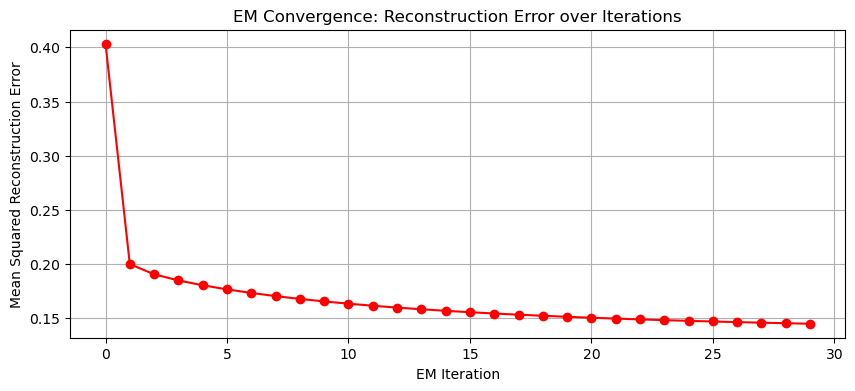

In [92]:
Ys, dts_all, _ = data_loading(patient_data)
num_factors = 10

Lambda_est, history_Lambda, mean_abs_history, recon_error_history = run_em_with_history(Ys, dts_all, k=num_factors, n_iter=30)

plot_em_performance(history_Lambda, recon_error_history, k=num_factors)
